In [2]:
#Realizar el analisis descrptivo del dataset de riesgo de credito, utilizando las siguientes tecnicas:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
import seaborn as sns
import numpy as np

In [3]:
#Cargar el dataset
path = kagglehub.dataset_download("ranadeep/credit-risk-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

data_dictionary = pd.read_excel(path + "/LCDataDictionary.xlsx")
print("Data dictionary:", data_dictionary.head())

data_loan = pd.read_csv(path + "/loan/loan.csv")
print("Loan data:", data_loan.head())

Path to dataset files: C:\Users\Jhanuar\.cache\kagglehub\datasets\ranadeep\credit-risk-dataset\versions\3
['LCDataDictionary.xlsx', 'loan']
Data dictionary:                LoanStatNew                                        Description
0               addr_state  The state provided by the borrower in the loan...
1               annual_inc  The self-reported annual income provided by th...
2         annual_inc_joint  The combined self-reported annual income provi...
3         application_type  Indicates whether the loan is an individual ap...
4  collection_recovery_fee                     post charge off collection fee


d:\RNA-Trabajo-2-main\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\Jhanuar\AppData\Local\Temp\ipykernel_25824\4007792662.py:10: DtypeWarning: Columns (0: desc, 1: verification_status_joint) have mixed types. Specify dtype option on import or set low_memory=False.
  data_loan = pd.read_csv(path + "/loan/loan.csv")


Loan data:         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  1077501    1296599     5000.0       5000.0           4975.0   36 months   
1  1077430    1314167     2500.0       2500.0           2500.0   60 months   
2  1077175    1313524     2400.0       2400.0           2400.0   36 months   
3  1076863    1277178    10000.0      10000.0          10000.0   36 months   
4  1075358    1311748     3000.0       3000.0           3000.0   60 months   

   int_rate  installment grade sub_grade  ... total_bal_il il_util  \
0     10.65       162.87     B        B2  ...          NaN     NaN   
1     15.27        59.83     C        C4  ...          NaN     NaN   
2     15.96        84.33     C        C5  ...          NaN     NaN   
3     13.49       339.31     C        C1  ...          NaN     NaN   
4     12.69        67.79     B        B5  ...          NaN     NaN   

  open_rv_12m  open_rv_24m max_bal_bc all_util total_rev_hi_lim inq_fi  \
0         NaN          Na

In [4]:
data_loan.columns = data_loan.columns.str.strip()
print("Cleaned column names:", data_loan.columns)


Cleaned column names: Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose',
       'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'annual_inc_joint', 'dti_joint', 'verificati

In [5]:
#Generar un resumen estadístico de las variables numéricas
summary_stats = data_loan.describe()
print("Summary statistics for numerical variables:")
print(summary_stats)


Summary statistics for numerical variables:
                 id     member_id      loan_amnt    funded_amnt  \
count  8.873790e+05  8.873790e+05  887379.000000  887379.000000   
mean   3.246513e+07  3.500182e+07   14755.264605   14741.877625   
std    2.282734e+07  2.411335e+07    8435.455601    8429.897657   
min    5.473400e+04  7.047300e+04     500.000000     500.000000   
25%    9.206643e+06  1.087713e+07    8000.000000    8000.000000   
50%    3.443327e+07  3.709528e+07   13000.000000   13000.000000   
75%    5.490814e+07  5.847135e+07   20000.000000   20000.000000   
max    6.861706e+07  7.354484e+07   35000.000000   35000.000000   

       funded_amnt_inv       int_rate    installment    annual_inc  \
count    887379.000000  887379.000000  887379.000000  8.873750e+05   
mean      14702.464383      13.246740     436.717127  7.502759e+04   
std        8442.106732       4.381867     244.186593  6.469830e+04   
min           0.000000       5.320000      15.670000  0.000000e+00   
25

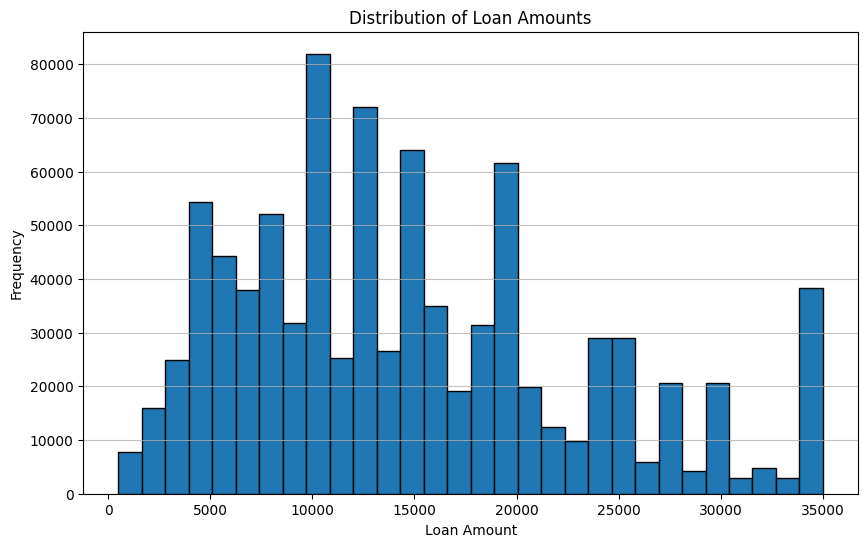

In [6]:
#Histograma con la columna "loan_amnt"
plt.figure(figsize=(10, 6))
plt.hist(data_loan["loan_amnt"], bins=30, edgecolor="k")
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

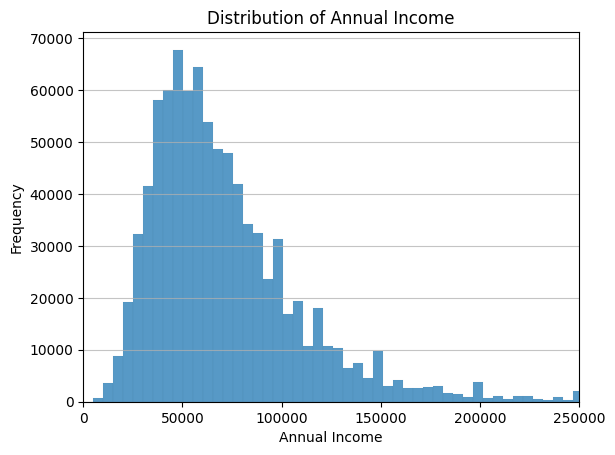

In [7]:
#Histogramas para la variable "annual_inc"
#Primero hay que convertir la columna "annual_inc" de cientifico a numérico

sns.histplot(x=data_loan['annual_inc'])
plt.ticklabel_format(style='plain', axis='x')#Evita la notación científica en el eje x
#Eliminar outliers para una mejor visualización
plt.xlim(0, 250000) #Limitar el eje x para eliminar outliers
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show() 

In [8]:
#Crear columna default binaria para analisis bivariado

status_map = {
    "Fully Paid":                                          0,
    "Does not meet the credit policy. Status:Fully Paid":  0,
    "Charged Off":                                         1,
    "Default":                                             1,
    "Late (31-120 days)":                                  1,
    "Does not meet the credit policy. Status:Charged Off": 1,
}

data_loan = data_loan[data_loan["loan_status"].isin(status_map)].copy()
data_loan["default"] = data_loan["loan_status"].map(status_map)

print(f"Filas para modelo: {len(data_loan):,}")
print(data_loan["default"].value_counts(normalize=True).mul(100).round(2))

Filas para modelo: 268,530
default
0    78.1
1    21.9
Name: proportion, dtype: float64


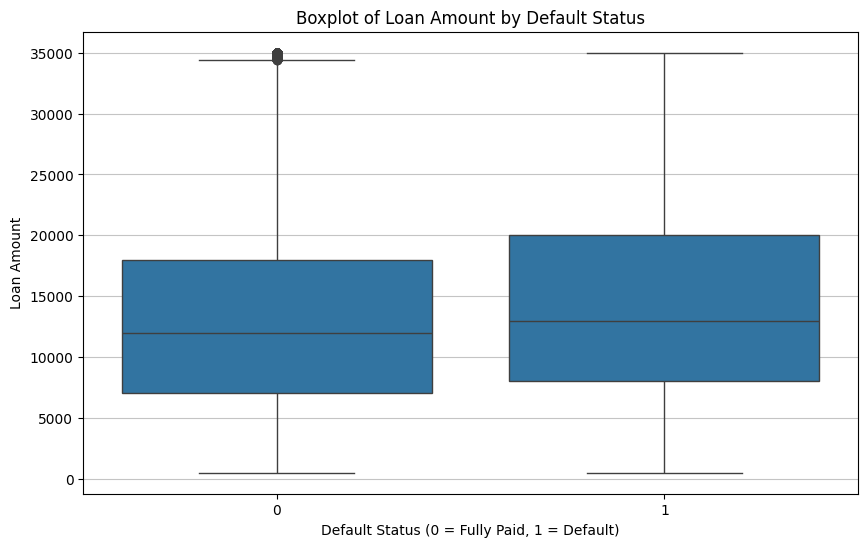

In [9]:
#Comparar la distribución de "loan_amnt" entre los grupos de "default" utilizando un boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="default", y="loan_amnt", data=data_loan)
plt.title("Boxplot of Loan Amount by Default Status")
plt.xlabel("Default Status (0 = Fully Paid, 1 = Default)")
plt.ylabel("Loan Amount")
plt.grid(axis="y", alpha=0.75)
plt.show()



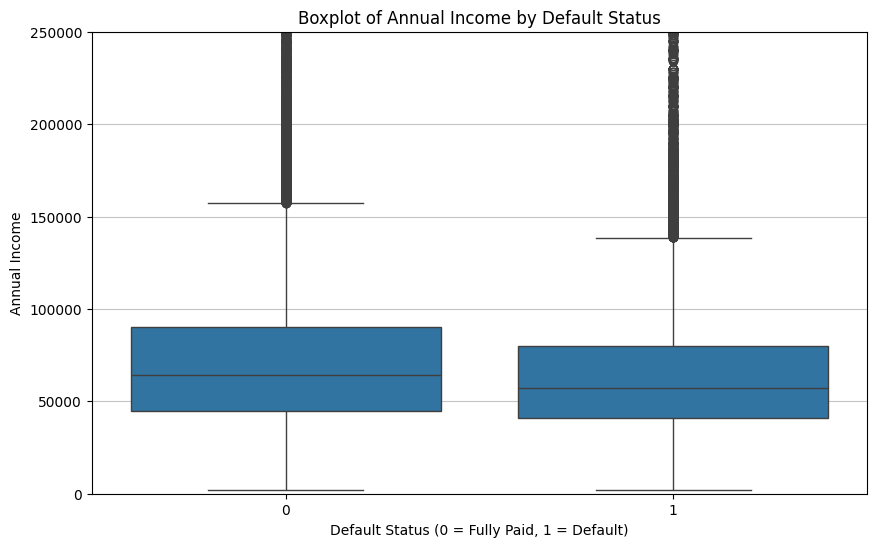

In [10]:
#Comparar la distribución de "annual_inc" entre los grupos de "default" utilizando un boxplot
#Esto sirve para ver si hay diferencias en los ingresos anuales entre los que incumplen y los que no incumplen
plt.figure(figsize=(10, 6))
sns.boxplot(x="default", y="annual_inc", data=data_loan)
plt.ylim(0, 250000) #Limitar el eje y para eliminar outliers
plt.title("Boxplot of Annual Income by Default Status")
plt.xlabel("Default Status (0 = Fully Paid, 1 = Default)")
plt.ylabel("Annual Income")
plt.grid(axis="y", alpha=0.75)
plt.show()


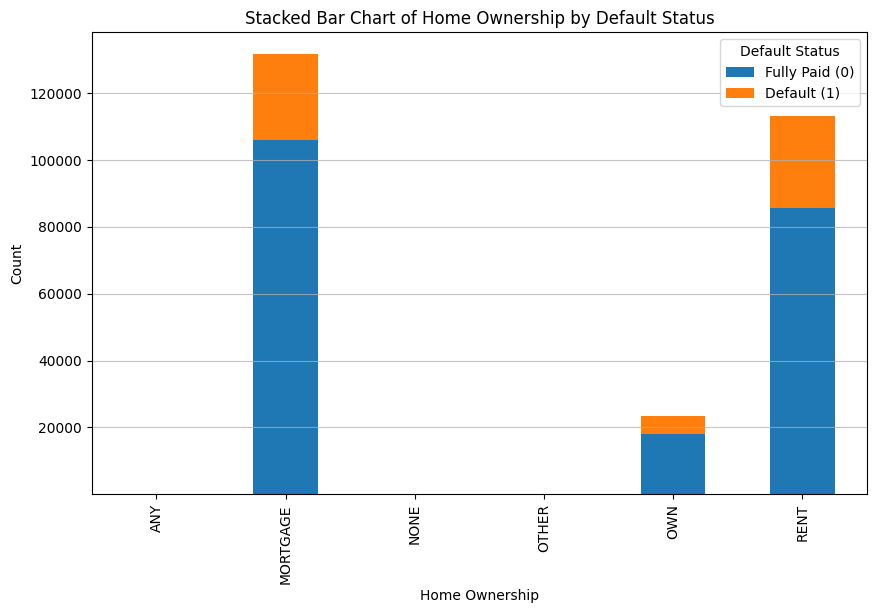

In [11]:
#Tablas apiladas para comparar si el estado de "home_ownership" (propiedad de vivienda) tiene alguna relación con el incumplimiento del préstamo
home_ownership_counts = data_loan.groupby(["home_ownership", "default"]).size().unstack(fill_value=0)
home_ownership_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Stacked Bar Chart of Home Ownership by Default Status")
plt.xlabel("Home Ownership")
plt.ylabel("Count")
plt.legend(title="Default Status", labels=["Fully Paid (0)", "Default (1)"])
plt.grid(axis="y", alpha=0.75)
plt.show()

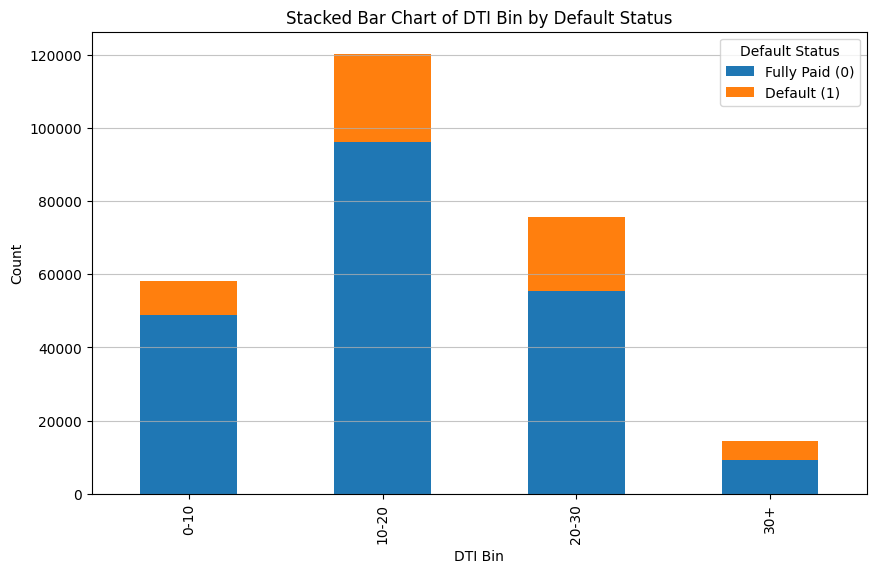

In [12]:
#Tablas apiladas para comparar si el dti (ratio de deuda a ingresos) tiene alguna relación con el default del préstamo
#Primero hay que convertir la columna "dti" de cientifico a numérico
data_loan["dti"] = pd.to_numeric(data_loan["dti"], errors="coerce")
data_loan["dti_bin"] = pd.cut(data_loan["dti"], bins
=[-float("inf"), 10, 20, 30, float("inf")], labels=["0-10", "10-20", "20-30", "30+"])
dti_counts = data_loan.groupby(["dti_bin", "default"]).size().unstack(fill_value=0)
dti_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Stacked Bar Chart of DTI Bin by Default Status")
plt.xlabel("DTI Bin")
plt.ylabel("Count")
plt.legend(title="Default Status", labels=["Fully Paid (0)", "Default (1)"])
plt.grid(axis="y", alpha=0.75)
plt.show()

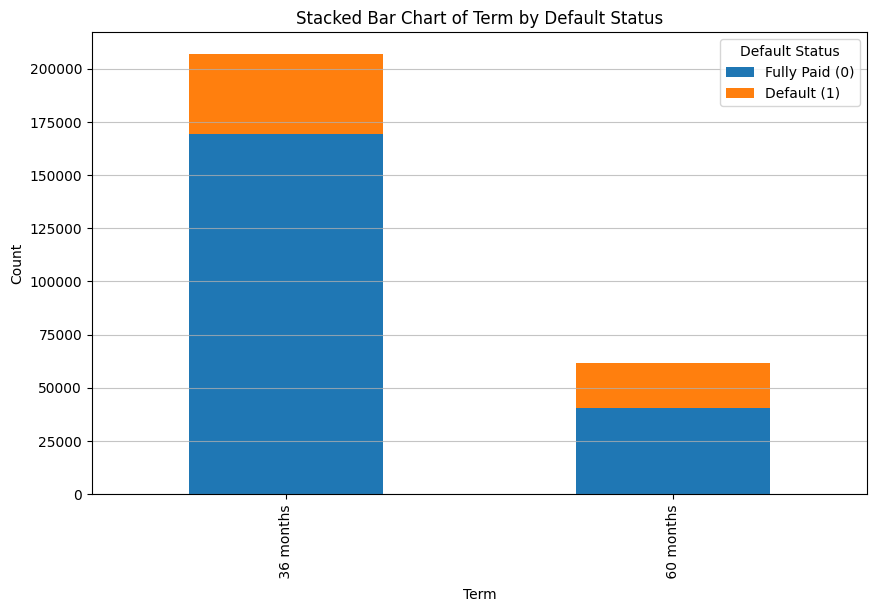

Percentages of Default Status by Term:
default           0         1
term                         
36 months  0.818828  0.181172
60 months  0.653996  0.346004


In [13]:
#Tablas apiladas para ver si la variable "terms" (plazo del préstamo) tiene alguna relación con el incumplimiento del préstamo
terms_counts = data_loan.groupby(["term", "default"]).size().unstack(fill_value=0)
terms_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Stacked Bar Chart of Term by Default Status")
plt.xlabel("Term")
plt.ylabel("Count")
plt.legend(title="Default Status", labels=["Fully Paid (0)", "Default (1)"])
plt.grid(axis="y", alpha=0.75)
plt.show()

#imprimir la relacion en porcentajes para cada categoria de term
terms_percentages = terms_counts.div(terms_counts.sum(axis=1), axis=0)
print("Percentages of Default Status by Term:")
print(terms_percentages)

                              default
default                      1.000000
annual_inc_joint             0.999226
recoveries                   0.390414
out_prncp                    0.350232
out_prncp_inv                0.350229
collection_recovery_fee      0.267243
int_rate                     0.254779
total_rec_late_fee           0.163300
dti                          0.133670
revol_util                   0.100138
funded_amnt                  0.071272
loan_amnt                    0.071006
funded_amnt_inv              0.069410
member_id                    0.066938
id                           0.065539
total_rec_int                0.060914
installment                  0.054684
inq_last_6mths               0.053434
delinq_2yrs                  0.031140
open_acc                     0.022784
collections_12_mths_ex_med   0.017143
pub_rec                      0.016347
mths_since_last_record       0.015227
acc_now_delinq               0.012561
tot_coll_amt                -0.001313
revol_bal   

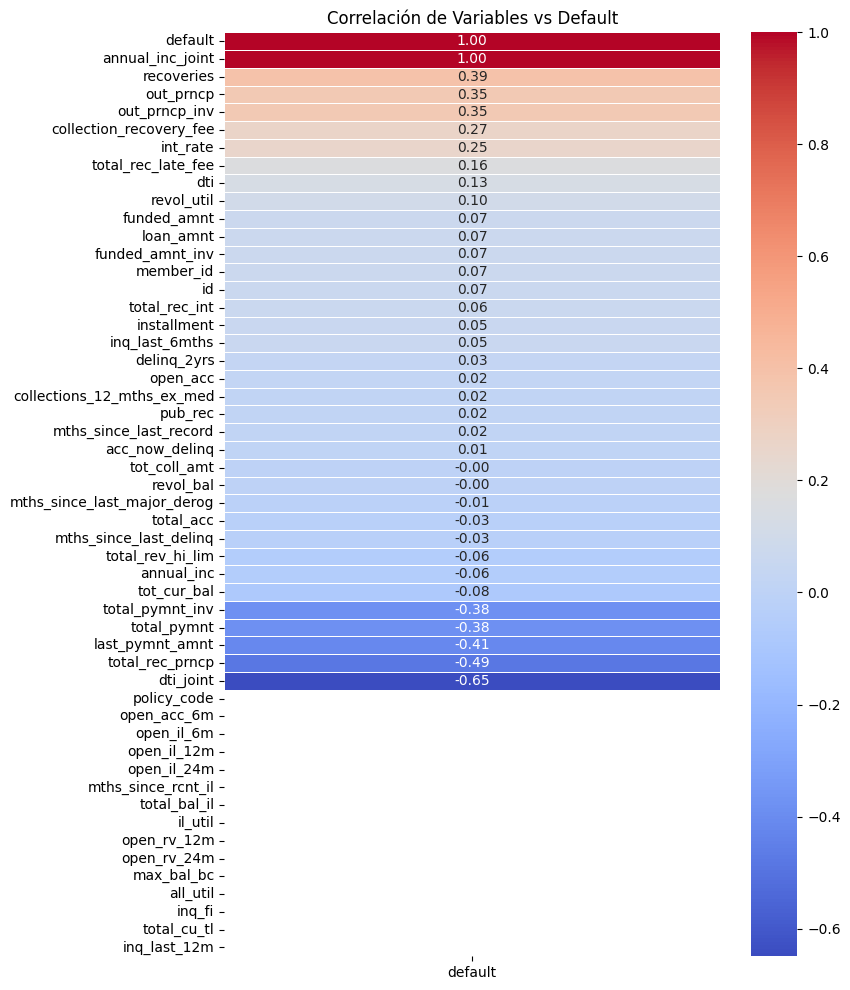

In [14]:
# 1. Seleccionar columnas numéricas
numeric_cols = data_loan.select_dtypes(include=["float64", "int64"]).columns
correlation_matrix = data_loan[numeric_cols].corr()
print(correlation_matrix[['default']].sort_values(by='default', ascending=False))

# 2. Extraer solo la correlación de 'Default' y ordenarla de mayor a menor
# Usamos [[ 'Default' ]] con doble corchete para que el resultado sea un DataFrame y no una Serie
default_corr = correlation_matrix[['default']].sort_values(by='default', ascending=False)

# 3. Ajustar el tamaño de la figura (ya no necesitas 30x28 porque es solo una columna)
plt.figure(figsize=(8, 12)) 

# 4. Crear el heatmap
sns.heatmap(default_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlación de Variables vs Default")
plt.show()


In [15]:
#Pasar todas estas graficas a texto para que se puedan interpretar sin necesidad de ver las graficas

default = data_loan["default"].value_counts()
print("Distribution of Default Status:")
print(default)
print('\n')

loan = data_loan["loan_amnt"].describe()
print("Summary statistics for Loan Amount:")
print(loan)
print('\n')


annual_inc = data_loan["annual_inc"].describe()
print("Summary statistics for Annual Income:")
print(annual_inc)
print('\n')

loan_default = data_loan.groupby("default")["loan_amnt"].describe()
print("Summary statistics for Loan Amount by Default Status:")
print(loan_default)
print('\n')

annual_inc_default = data_loan.groupby("default")["annual_inc"].describe()
print("Summary statistics for Annual Income by Default Status:")
print(annual_inc_default)
print('\n')

home_ownership_default = data_loan.groupby(["home_ownership", "default"]).size().unstack(fill_value=0)
print("Counts of Home Ownership by Default Status:")
print(home_ownership_default)
print('\n')

dti_default = data_loan.groupby(["dti_bin", "default"]).size().unstack(fill_value=0)
print("Counts of DTI Bin by Default Status:")
print(dti_default)
print('\n')

terms_default = data_loan.groupby(["term", "default"]).size().unstack(fill_value=0)
print("Counts of Term by Default Status:")
print(terms_default)
print('\n')



Distribution of Default Status:
default
0    209711
1     58819
Name: count, dtype: int64


Summary statistics for Loan Amount:
count    268530.000000
mean      13610.482255
std        8156.553502
min         500.000000
25%        7350.000000
50%       12000.000000
75%       18450.000000
max       35000.000000
Name: loan_amnt, dtype: float64


Summary statistics for Annual Income:
count    2.685260e+05
mean     7.239188e+04
std      5.844719e+04
min      1.896000e+03
25%      4.500000e+04
50%      6.200000e+04
75%      8.700000e+04
max      8.706582e+06
Name: annual_inc, dtype: float64


Summary statistics for Loan Amount by Default Status:
            count          mean          std    min     25%      50%      75%  \
default                                                                         
0        209711.0  13303.757433  8053.295369  500.0  7075.0  12000.0  18000.0   
1         58819.0  14704.067138  8424.184425  500.0  8000.0  13000.0  20000.0   

             max  
default